In [ ]:
# Name - Aman Kumar Sharma
# Roll - 2501940041
# MCA AI & ML

In [2]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [3]:
import pandas as pd  # used for handling datasets (like Excel/CSV)

# Read the CSV file into a DataFrame
df = pd.read_csv("IMDB Dataset.csv")

# Show first 5 rows to understand data
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# See column names
print(df.columns)

# See dataset info (types, null values)
df.info()

Index(['review', 'sentiment'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
# X = input text (movie reviews)
X = df['review']

# y = output labels (positive / negative)
y = df['sentiment']

In [6]:
# Convert 'positive' → 1 and 'negative' → 0
y = y.map({'positive': 1, 'negative': 0})

In [7]:
import re  # used for text cleaning (regular expressions)

# Function to clean text
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove punctuation, numbers
    return text

# Apply cleaning to all reviews
X = X.apply(clean_text)

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Create tokenizer (keep top 10,000 words only)
tokenizer = Tokenizer(num_words=10000)

# Learn vocabulary from text
tokenizer.fit_on_texts(X)

# Convert text into sequences of numbers
X_seq = tokenizer.texts_to_sequences(X)

In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Make all sequences length = 200
X_pad = pad_sequences(X_seq, maxlen=200)

In [10]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42
)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Create model
model_rnn = Sequential()

# Embedding layer → converts numbers into dense vectors
model_rnn.add(Embedding(input_dim=10000, output_dim=32, input_length=200))

# Simple RNN layer → processes sequence
model_rnn.add(SimpleRNN(32))

# Output layer → binary classification
model_rnn.add(Dense(1, activation='sigmoid'))

# Compile model
model_rnn.compile(
    optimizer='adam',                # optimization algorithm
    loss='binary_crossentropy',      # for binary classification
    metrics=['accuracy']             # evaluation metric
)

# Train model
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=3,
    validation_data=(X_test, y_test)
)

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 42ms/step - accuracy: 0.7401 - loss: 0.5192 - val_accuracy: 0.8359 - val_loss: 0.3797
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 42ms/step - accuracy: 0.8514 - loss: 0.3576 - val_accuracy: 0.8287 - val_loss: 0.3884
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.8724 - loss: 0.3107 - val_accuracy: 0.8177 - val_loss: 0.4464


In [12]:
from tensorflow.keras.layers import LSTM

# Create model
model_lstm = Sequential()

# Embedding layer
model_lstm.add(Embedding(10000, 32, input_length=200))

# LSTM layer → better memory than RNN
model_lstm.add(LSTM(32))

# Output layer
model_lstm.add(Dense(1, activation='sigmoid'))

# Compile
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=3,
    validation_data=(X_test, y_test)
)

Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 89s 68ms/step - accuracy: 0.8164 - loss: 0.4030 - val_accuracy: 0.8702 - val_loss: 0.3069
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.9022 - loss: 0.2523 - val_accuracy: 0.8786 - val_loss: 0.2817
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 69ms/step - accuracy: 0.9225 - loss: 0.2052 - val_accuracy: 0.8730 - val_loss: 0.2909


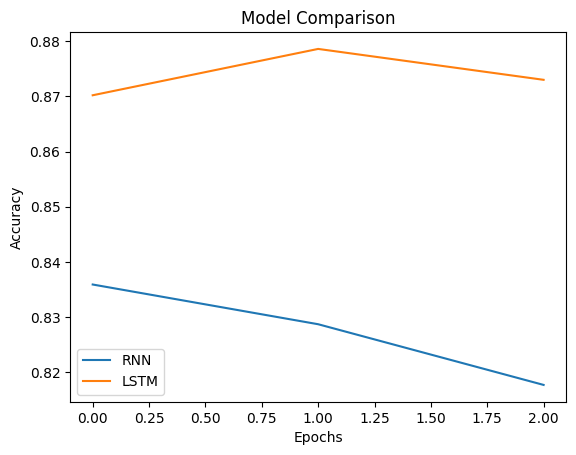

In [13]:
import matplotlib.pyplot as plt

# Plot validation accuracy for both models
plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

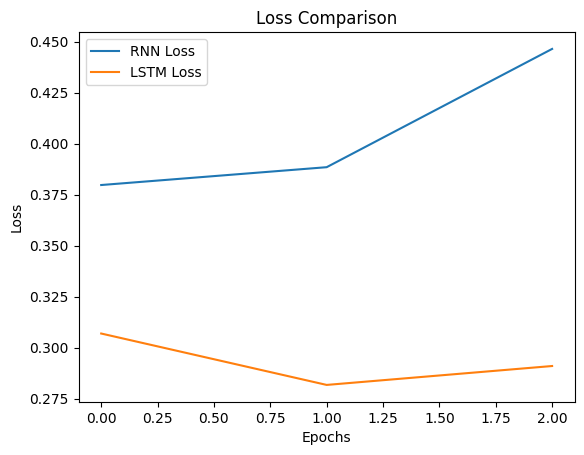

In [14]:
plt.plot(history_rnn.history['val_loss'], label='RNN Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Loss')

plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

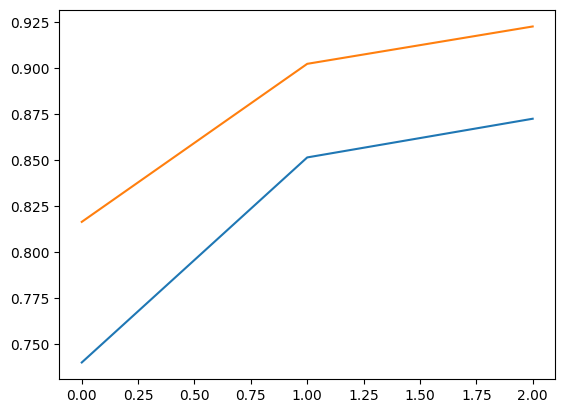

In [15]:
plt.plot(history_rnn.history['accuracy'], label='RNN Train')
plt.plot(history_lstm.history['accuracy'], label='LSTM Train')

In [16]:
from sklearn.metrics import classification_report

# Predict using LSTM model
y_pred = (model_lstm.predict(X_test) > 0.5).astype("int32")

# Print evaluation metrics
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
              precision    recall  f1-score   support

           0       0.91      0.82      0.87      4961
           1       0.84      0.92      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000

